<a href="https://colab.research.google.com/github/dhruvsuri8106-code/ECON-3916---Statistical-and-Machine-Learning/blob/main/Lab%2015%20/%20Lab_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


In [2]:
n_train = 50
n_test = 200
noise_std = 0.3

def true_function(x):
    return np.sin(2 * np.pi * x)

# Training data
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)

# Test data (separate - the model never sees this)
x_test = np.sort(np.random.uniform(0, 1, n_test))
y_test = true_function(x_test) + np.random.normal(0, noise_std, n_test)

x_plot = np.linspace(0, 1, 300)

print(f'Training set: {n_train} observations')
print(f'Test set:     {n_test} observations')
print(f'Noise std:    {noise_std} (sigma^2 = {noise_std**2:.2f})')

Training set: 50 observations
Test set:     200 observations
Noise std:    0.3 (sigma^2 = 0.09)


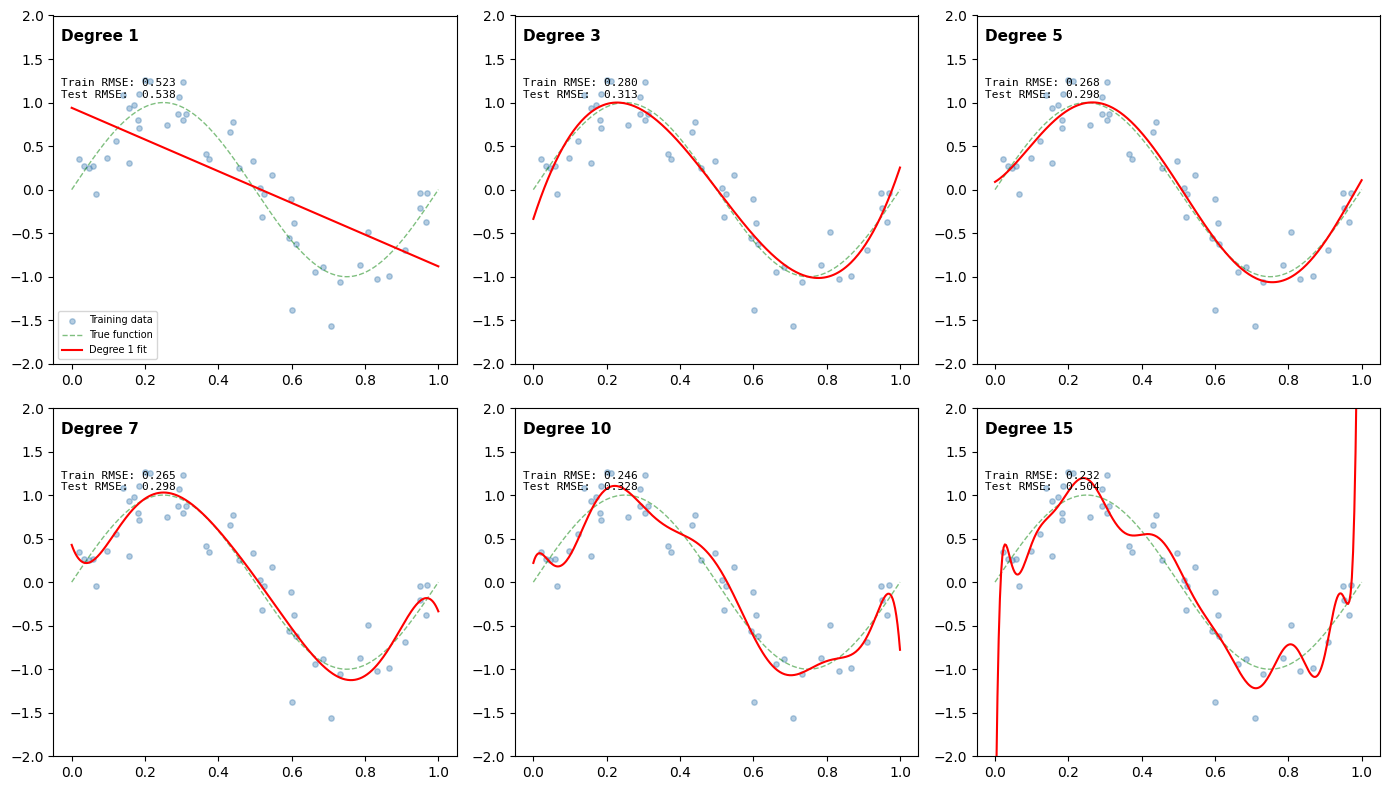

In [3]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

In [6]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = fold[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1, 1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(x_fold_test.reshape(-1, 1))
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors

In [7]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')

sklearn 5-fold CV RMSE (degree 3): 0.7226 +/- 0.8230
Per-fold RMSE: [0.33804966 0.22992916 0.24712496 0.43602712 2.36206012]


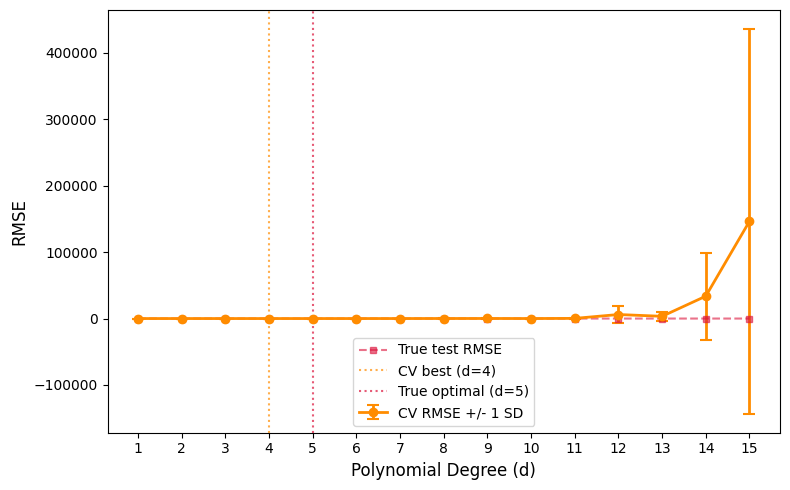

CV-selected degree: 4
True optimal degree: 5


In [11]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []
test_errors = [] # Initialize test_errors list

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train) # Fit model to calculate test error as well

    # Calculate CV RMSE
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

    # Calculate true test RMSE
    y_pred_test = model.predict(x_test.reshape(-1, 1))
    current_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_errors.append(current_test_rmse)

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)
test_errors = np.array(test_errors) # Convert to numpy array

# Find the degree with the minimum true test RMSE
best_degree = list(all_degrees)[np.argmin(test_errors)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7, label=f'CV best (d={cv_best_degree})')
ax.axvline(x=best_degree, color='crimson', linestyle=':',
           alpha=0.7, label=f'True optimal (d={best_degree})') # Add line for true optimal degree

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [10]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [12]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')


Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397
